In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Load your April 2011 dataset
ds = xr.open_dataset('wrfout_d01_2011-04-28_00:00:00')

# 1. Define your geographic boundaries
lat_min, lat_max = 25.0, 50.0
lon_min, lon_max = -125.0, -65.0

# 2. Create a mask based on the 2D coordinate variables
# Note: Check if your file uses 'XLAT' or 'lat' in ds.coords
mask = (
    (ds.XLAT >= lat_min) & (ds.XLAT <= lat_max) & 
    (ds.XLONG >= lon_min) & (ds.XLONG <= lon_max)
)

# 3. Apply the mask
# 'drop=True' removes the grid cells outside your range
subset = ds.where(mask, drop=True)

# Save your new regional file
!rm regional_wrfout_2011-04-28_00:00:00.nc
subset.to_netcdf('regional_wrfout_2011-04-28_00:00:00.nc')

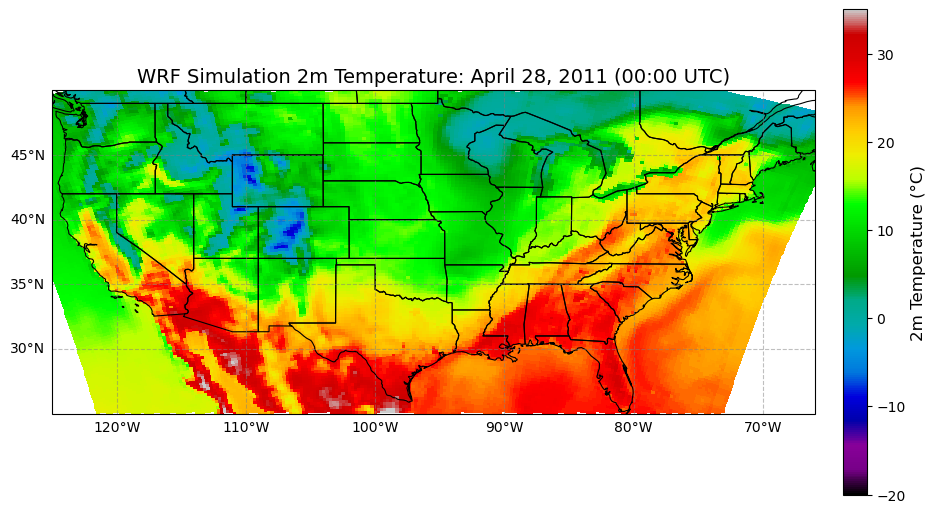

In [5]:
# 1. Load your subsetted data
ds = xr.open_dataset('regional_wrfout_2011-04-28_00:00:00.nc')

# Extract 2m Temp and convert Kelvin to Celsius
t2 = ds['T2'].isel(Time=0) - 273.15

# 2. Point to your unzipped shapefile
shp_path = 'state_lines/ne_50m_admin_1_states_provinces.shp'

# Define universal constants for both plots
T_MIN, T_MAX = -20, 35 

fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add State Lines
reader = shpreader.Reader(shp_path)
ax.add_geometries(reader.geometries(), ccrs.PlateCarree(), 
                  facecolor='none', edgecolor='black', linewidth=0.8)

# Plot with FIXED LIMITS
mesh = t2.plot(
    ax=ax, 
    x='XLONG', 
    y='XLAT', 
    transform=ccrs.PlateCarree(),
    cmap='nipy_spectral', 
    vmin=T_MIN,      # Fixed Min
    vmax=T_MAX,      # Fixed Max
    add_colorbar=False 
)

# Use the FIG object to add the colorbar to avoid the UserWarning
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.03, shrink=0.7)
cbar.set_label('2m Temperature (°C)', fontsize=12)

# Standardize the map zoom (Extents)
ax.set_extent([-125, -66, 25, 50], crs=ccrs.PlateCarree())

# Formatting
gl = ax.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False, 
                  linestyle='--', color='gray', alpha=0.5)
gl.top_labels = False    
gl.right_labels = False  
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

plt.title("WRF Simulation 2m Temperature: April 28, 2011 (00:00 UTC)", fontsize=14)
plt.show()